# Этап №3. | AI/ML | Парсинг данных

**Цель этапа:** подготовка нормативной документации (ПУЭ) для векторного поиска — от исходников до загрузки в векторную базу.



**Пайплайн:** `raw` → `extracted` → `chunked` → `embeddings` (векторная база)

**Содержание:**
1. Конвертация исходных файлов raw
2. Редактирование файлов extracted
3. Чанкирование файлов extracted
4. Векторная база данных
5. Загрузка в векторную базу данных и тестовые запросы

## 1. Конвертация исходных файлов raw

На данном этапе была выполнена конвертация исходных документов MS Word (формат DOCX) нормативной документации «ПРАВИЛА УСТРОЙСТВА ЭЛЕКТРОУСТАНОВОК» (ПУЭ) в формат Markdown (MD).

**Цель конвертации:** Преобразование структурированных документов в текстовый формат, удобный для дальнейшей обработки и создания векторной базы знаний.

**Основные результаты:**
- Сконвертированные файлы сохранены в директории `data/extracted`
- Изображения из документов извлечены и размещены в отдельных папках с префиксом `image_*`
- Сохранена структура документа с заголовками, списками и ссылками на изображения
- Каждая глава ПУЭ представлена отдельным MD-файлом (например: 1.1.md, 1.2.md, ..., 7.10.md)

**Процесс конвертации включал следующие этапы:**
1. Извлечение изображений из DOCX-файлов
2. Преобразование форматирования документа в Markdown-разметку
3. Создание ссылок на извлеченные изображения
4. Сохранение результатов в структурированном виде

Подробное описание каждого подэтапа представлено в следующих разделах.

### 1.1. Исходные данные (raw)

Исходные данные для конвертации представляют собой нормативную документацию в формате Microsoft Word (DOCX).

**Расположение исходных файлов:**

| Путь | Содержимое |
|------|------------|
| `data/raw/Нормативная база/ПУЭ/` | Исходные DOCX-файлы ПУЭ (Правила устройства электроустановок) |
| `data/raw/База исходники/` | Прочие нормативные документы в формате DOCX |

**Характеристики исходных данных:**

- Формат документов: Microsoft Word (DOCX)
- Структура: каждая глава ПУЭ находится в отдельном файле
- Содержимое: текст, таблицы, изображения, форматирование
- Общее количество файлов: более 70 глав ПУЭ

На скриншотах ниже представлена структура директорий с исходными файлами:



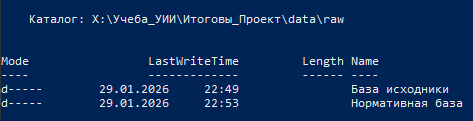  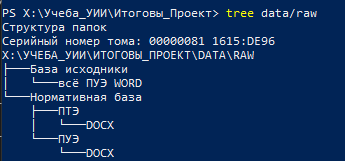

### 1.2. Результат конвертации (extracted)

После выполнения конвертации получены следующие результаты:

**Структура выходных данных:**

- Директория: [data/extracted](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/data/extracted)
- Файлы формата Markdown (*.md) по главам: 1.1.md, 1.2.md, ..., 7.10.md
- Рядом с каждым .md-файлом создана папка с изображениями соответствующей главы
- Именование папок с изображениями: `image_[номер_главы]` (например, `image_1.7`)

**Особенности конвертированных файлов:**

- Сохранена иерархическая структура документа
- Заголовки преобразованы в Markdown-разметку (###, ##, #)
- Изображения вынесены в отдельные папки со ссылками в тексте
- Таблицы сохранены в Markdown-формате

**Пример результата:**

Ниже представлен фрагмент файла 1.7.md (первые 20–30 строк), демонстрирующий структуру конвертированного документа с заголовками, пунктами Предисловия и ссылками на рисунки 1.7.3, 1.7.4:



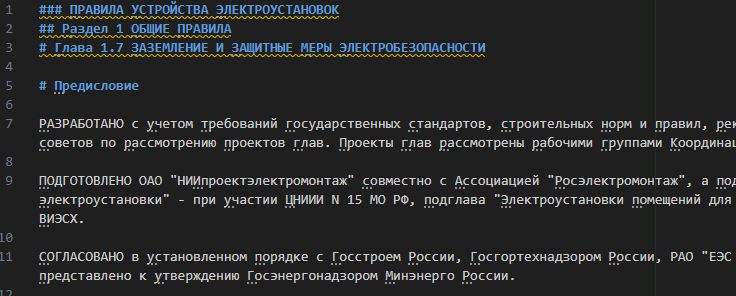

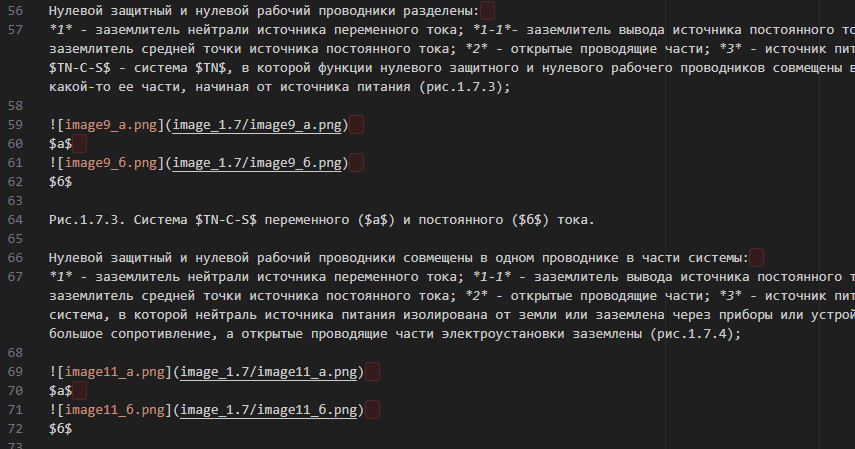

### 1.3. Используемые скрипты

Для автоматизации процесса конвертации были разработаны специализированные Python-скрипты:

| Скрипт | Назначение | Основные функции |
|--------|------------|------------------|
| [docx_to_md_images_1.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_mds/docx_to_md_images_1.py) | Обработка одного файла | Извлечение изображений, конвертация форматирования, создание Markdown-файла |
| [generator.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_mds/generator.py) | Массовая обработка | Пакетная обработка всех файлов в директории, логирование процесса |

**Процесс работы скриптов:**

1. **docx_to_md_images_1.py** выполняет следующие операции:
   - Открывает DOCX-файл и анализирует его структуру
   - Извлекает все изображения и сохраняет их в отдельную папку
   - Преобразует форматирование текста в Markdown-разметку
   - Создает ссылки на извлеченные изображения
   - Сохраняет результат в MD-файл

2. **generator.py** обеспечивает:
   - Автоматический обход всех DOCX-файлов в исходной директории
   - Вызов функции конвертации для каждого файла
   - Логирование процесса обработки
   - Обработку ошибок и создание отчета о результатах

**Пример работы:**

Ниже представлен лог конвертации файла 7.5.docx в 7.5.md. Процесс включает извлечение изображений, их копирование в папку `image_7.5`, и последующее создание Markdown-файла:



Пример. Лог конвертации файла 7.5.docx в 7.5.md. Перед формированием 7.5.md в начале происходит извление изображений, копирование их в папку \image_7.5

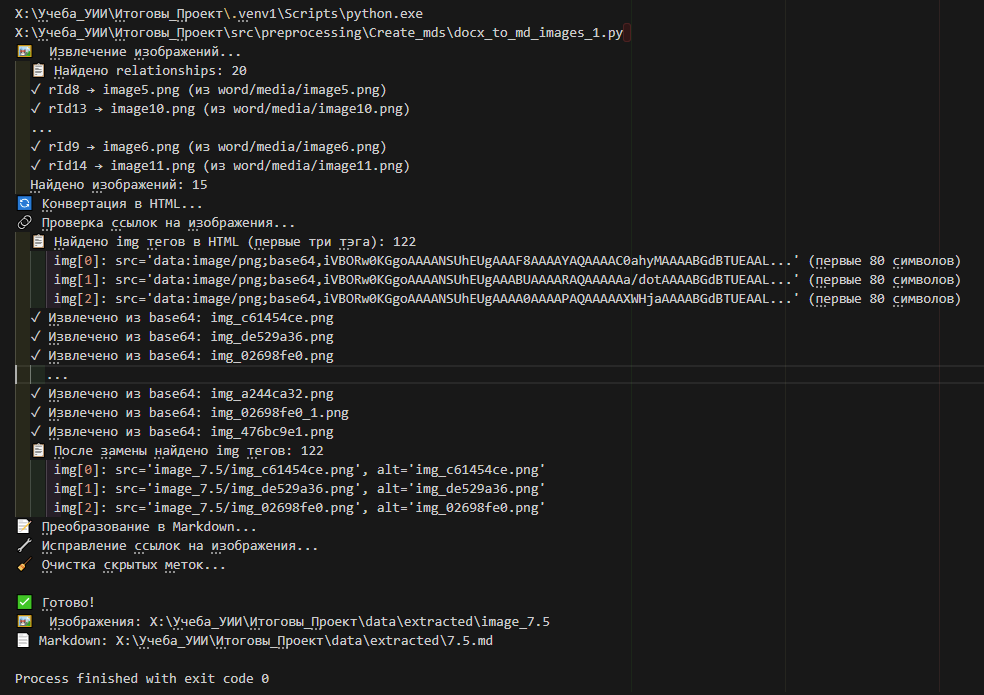

## 2. Редактирование файлов extracted

На данном этапе выполнено постобработка сконвертированных файлов Markdown (extracted) нормативной документации ПУЭ для обеспечения качества данных при дальнейшем чанкировании и использовании в RAG-системе.

**Цель редактирования:** Подготовка MD-файлов к корректной индексации и векторному поиску — устранение артефактов конвертации и улучшение структуры контента для эффективного извлечения релевантной информации.

**Основные результаты:**
- Отредактированы файлы extracted *.md (глава 1) для отработки пайплайна
- Устранены дублирующиеся изображения в тексте
- Формулы и таблицы выделены в отдельные блоки для корректного отображения в RAG
- Сохранена семантическая структура документов

**Процесс редактирования включал следующие этапы:**
1. Анализ сконвертированных MD-файлов на наличие артефактов
2. Удаление повторяющихся изображений
3. Выделение формул (LaTeX) и таблиц в отдельные блоки
4. Проверка целостности структуры документа

Подробное описание с примерами представлено в следующих подразделах.



### 2.1. Пример правок (пункт 2.5.11)

Ниже представлен пример редактирования фрагмента из главы 2.5 — пункт **2.5.11. Основными характеристиками нагрузок являются их нормативные значения, которые устанавливаются настоящими Правилами, а для нагрузок, не регламентированных ими, - в соответствии со строительными нормами и правилами**.

На иллюстрациях показано сравнение версии до и после правок: устранение дублирования изображений и улучшение оформления формул и таблиц.

|До правок|После правок|
|-|-|
|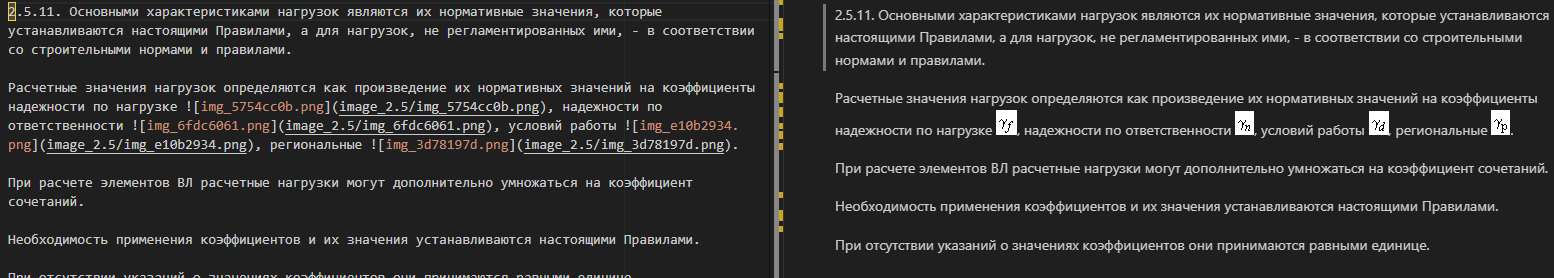|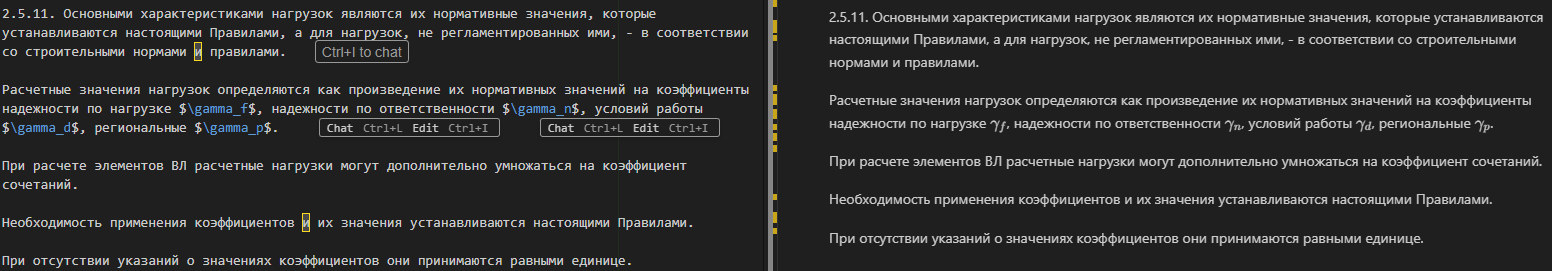|

## 3. Чанкирование файлов extracted

На данном этапе выполнено преобразование отредактированных файлов Markdown (extracted) в формат JSON Lines (JSONL) с разбиением на семантические чанки для последующей индексации в векторной базе данных.

**Цель чанкирования:** Подготовка структурированных фрагментов документации для эффективного векторного поиска — каждый чанк содержит логически завершённый пункт правил с полным контекстом (Раздел → Глава → Пункт).

**Основные результаты:**
- Файлы `*.chunked.jsonl` сохранены в директории `data/chunked`
- Каждая строка JSONL — отдельный чанк с полями `id`, `metadata`, `content`
- Сохранена иерархия документа: Document, Section, Chapter, Paragraph, Clause
- Изображения и таблицы остаются внутри чанков (флаги `contains_images`, `contains_tables`)

**Стратегия чанкирования:**
- Разбиение по пунктам по шаблону (X.Y.Z) — один пункт = один чанк
- Парсинг структуры MD: заголовки ###, ##, #, нумерованные пункты (1.2.3)
- Изображения из папок `image_*` копируются в выходную директорию

Подробное описание каждого подэтапа представлено в следующих разделах.

### 3.1. Результат (chunked)

После выполнения чанкирования получены следующие результаты:

**Расположение выходных данных:**

| Путь | Содержимое |
|------|------------|
| [data/chunked](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/data/chunked) | Файлы `*.chunked.jsonl` по главам ПУЭ |
| `data/chunked/image_*` | Папки с изображениями, скопированными из extracted |

**Структура выходных файлов:**

- Формат: JSON Lines (JSONL) — каждая строка файла — отдельный JSON-объект
- Именование: `{номер_главы}.chunked.jsonl` (например: `1.1.chunked.jsonl`, `4.4.chunked.jsonl`, `6.5.chunked.jsonl`)
- Соответствие: один MD-файл из `extracted` → один JSONL-файл в `chunked`

**Характеристики чанков:**

- Каждый чанк — логически завершённый пункт правил (X.Y.Z)
- Сохранён полный контекст: Document, Section, Chapter, Paragraph, Clause
- Изображения и таблицы встроены в контент чанка

На скриншоте ниже представлена структура директории с результатами чанкирования:



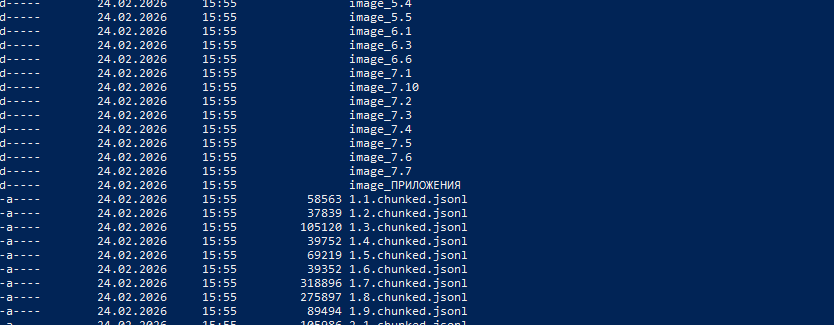

### 3.2. Пример чанка (структура)

Каждая строка JSONL-файла представляет собой JSON-объект со следующей структурой:

**Основные поля чанка:**

| Поле | Описание |
|------|----------|
| `id` | Уникальный идентификатор (например, `pue_1.1.1_543e2d24` или `pue_para_Заголовок_abc12345`) |
| `metadata` | Метаданные: Document, Section, Chapter, Paragraph, Clause, source_file, contains_tables, contains_images |
| `content` | Текст пункта с полным контекстом (Раздел → Глава → Пункт) |
| `created_at` | Временная метка создания чанка |

**Структура metadata:**

- `Document` — название документа (ПУЭ)
- `Section` — раздел (например, «Раздел 1»)
- `Chapter` — глава (например, «Глава 1.7 - …»)
- `Paragraph` — параграф/подраздел
- `Clause` — номер пункта (1.2.3)
- `source_file` — исходный MD-файл
- `contains_tables` — наличие таблиц в чанке
- `contains_images` — наличие изображений в чанке

*Для наглядности ниже представлены несколько чанков в неотформатированном и отформатированном виде (json.dumps с indent):*

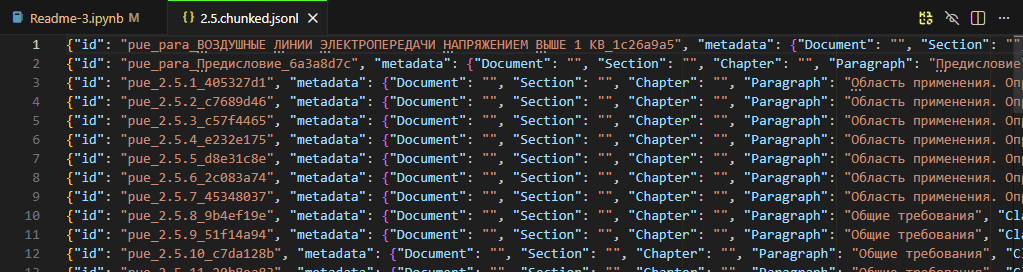

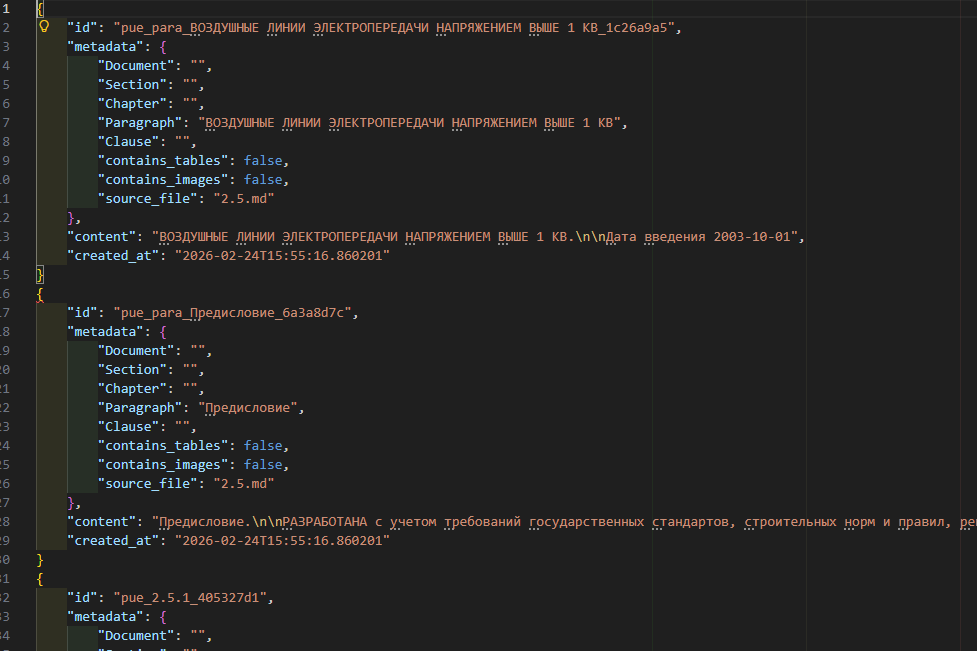

### 3.3. Используемые скрипты

Для автоматизации процесса чанкирования были разработаны специализированные Python-скрипты:

| Скрипт | Назначение | Основные функции |
|--------|------------|------------------|
| [md_to_chunked_2.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_chunkeds/md_to_chunked_2.py) | Обработка одного файла | Парсинг структуры MD (PueMetadataParser), разбиение на чанки по пунктам, копирование изображений, запись JSONL |
| [generator.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_chunkeds/generator.py) | Массовая обработка | Асинхронная пакетная обработка всех MD-файлов из `data/extracted`, логирование процесса |

**Процесс работы скриптов:**

1. **md_to_chunked_2.py** — чтение MD-файла, парсинг заголовков и пунктов (###, ##, #, X.Y.Z), формирование чанков с метаданными, копирование изображений из папок `image_*` в выходную директорию, запись в `{глава}.chunked.jsonl`
2. **generator.py** — поиск всех `*.md` в `data/extracted`, параллельная конвертация (по умолчанию 4 потока), вывод лога по каждому файлу

*Для наглядности: в логе отображается количество чанков на файл 2.5 md *

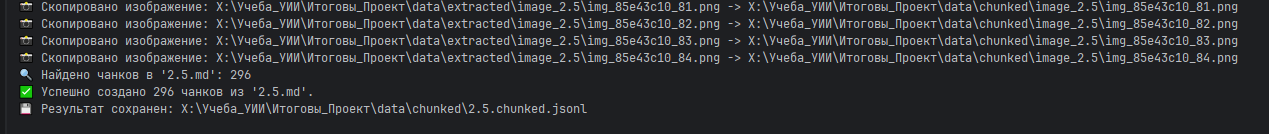

## 4. Векторная БД Milvus

В качестве хранения эмбеддингов выбираем векторную базу данных Milvus.


**Инфраструктура:**
- [infra](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/infra) — docker-compose для Milvus
- Attu — веб-интерфейс для просмотра коллекций и данных

### 4.1. Что показать в Milvus (Attu)

| Материал | Описание |
|----------|----------|
| Скриншот списка коллекций | Имя коллекции `diplom_multimodal`, количество сущностей |
| Скриншот схемы коллекции | Поля: id, embedding (vector), chapter, text, has_image, image_paths, … |
| Скриншот данных | Несколько записей с текстом и метаданными |

*Для наглядности: 1–2 скриншота Attu — коллекции и пример записей*

## 5. Загрузка чанков в БД и тестовые запросы

Загружены чанки в Milvus. Отдельно — текст и картинки (картинки через CLIP — в планах). Эмбеддинги текста считаются при загрузке.

### 5.1. Скрипты

| Скрипт | Назначение |
|--------|------------|
| [load_data.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/load_data.py) | Загрузка данных в коллекцию |
| [multimodal_rag.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/multimodal_rag.py) | Класс MultimodalRAG — загрузка, поиск |
| [query_test.py](https://github.com/kirag-ozyaz/Diplom_AI/blob/main/src/preprocessing/Create_embeddings/query_test.py) | Тестовые запросы к готовой коллекции |

*Для наглядности: лог загрузки — количество загруженных чанков, время*

### 5.2. Что показать по запросам

| Материал | Описание |
|----------|----------|
| Пример запроса | Текст запроса (напр. «система заземления» или «нулевой защитный проводник») |
| Топ-N результатов | Для каждого: score, chapter, фрагмент текста, наличие изображений |
| Таблица | Запрос → Найденный пункт (1.1.X) → Score |

*Для наглядности: вывод `query_test.py` — 2–3 примера запросов с результатами*

---

## Итог этапа

| Статус | Описание |
|--------|----------|
| ✅ | Данные в векторной БД Milvus |
| ✅ | Тестовые запросы проверяются |
| 🔜 | Доработка RAG, поиск по картинкам (CLIP) |

